[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jordy-Castillo/FC_Jordy-Castillo-Trabajos/blob/main/Taller04/FC_Taller04_JordyCastillo.ipynb)

# **FISICA COMPUTACIONAL - TALLER #4**
* **Tema:** Generación de Números Aleatorios
* **Lenguaje:** Python
* **Estudiante:** Jordy Castillo Jordán
* **Fecha:** 08/10/2026



## **Parte A — Funciones de la simulación**

Complete las tres funciones de la siguiente celda:

1. `generar_paso(rng,a)`: consuma **un** número del generador recibido y devuelva $+a$ o $-a$.
2. `caminar(N,a,rng)`: valide $N\geq0$ y $a>0$; devuelva **$N+1$ posiciones**, incluida $x_0=0$.
3. `simular_caminatas(K,N,a,semilla,generador=None)`: valide $K>0$, $N\geq0$ y $a>0$. Si `generador` es `None`, cree **un solo** `random.Random(semilla)` al inicio; si se entrega un generador, úselo en su lugar (lo necesitará en la Parte D). Pase ese mismo generador a cada caminata y acumule $x_n$ y $x_n^2$ para todos los $n$.
4. Divida cada suma por $K$ **después** del ciclo sobre caminantes. Devuelva `(media_x, media_x2)`.

Use `ValueError` para parámetros inválidos. No reinicie la semilla dentro del ciclo de caminantes: eso repetiría la misma trayectoria $K$ veces.

<div style="background-color:#eef7ee; border-left:5px solid #4caf50; padding:10px 15px; margin:10px 0;"><b>Prueba manual:</b> para <code>N=0</code>, la trayectoria y ambos promedios deben contener solamente el cero inicial.</div>

In [4]:
import random            #biblioteca que necesitaremos para el paso 3

## PASO 1 ##
def generar_paso(rng, a):
  u = rng.random()                                      #definir el numero pseudoaleatorio u (que pertenece al rango de 0 a 1)
                                                        #Un paso de longitud a: derecha si u<0.5, izquierda si u>=0.5.
  if u < 0.5:
    return a
  else:
    return -a

  raise NotImplementedError("Complete generar_paso")

## PASO 2 ##
def caminar(N, a, rng):

#Construye [x_0, x_1, ..., x_N] a partir del generador recibido.
  if N < 0 or a <= 0:
    raise ValueError("Parametros invalidos; (N) debe ser mayor o igual a 0 y (a) debe ser mayor a 0")

#iniciamos la posicion inicial y creamos una lista para las X
  x = 0.0
  posiciones =[x]

#generamos los pasos con un ciclo for
  for _ in range(N):
     paso = generar_paso(rng, a)
     x += paso
     posiciones.append(x)

  return posiciones
  raise NotImplementedError("Complete caminar")


## PASO 3 ##
def simular_caminatas(K, N, a, semilla, generador=None):
  if K <= 0 or N < 0 or a <= 0:
    raise ValueError("Parametros invalidos; (K) debe ser mayor a 0, (N) debe ser mayor o igual a 0 y (a) debe ser mayor a 0")

  #creamos el generador unico
  if generador is None:
     rng = random.Random(semilla)
  else:
     rng = generador

  #definimos los acumuladores en cero inicialmente (variables)
  suma_x = [0.0] * (N + 1)
  suma_x2 = [0.0] * (N + 1)

  #creamos un ciclo for sobre los caminantes y otro del interno para los pasos
  for _ in range(K):
     trayectoria = caminar(N, a, rng)
     for n in range(N+1):
       x_n = trayectoria[n]
       suma_x[n] += x_n
       suma_x2[n] += x_n**2

## PASO 4 ##

  #Promedia x_n y x_n² en K caminatas; incluye el índice n=0.
  media_x= [sx / K for sx in suma_x]
  media_x2= [sx2 / K for sx2 in suma_x2]

  return media_x, media_x2
  raise NotImplementedError("Complete simular_caminatas")

## **Parte B — Ajuste y coeficiente de difusión**

Complete el ajuste con las sumas de la sección 4. La función debe devolver `(pendiente, intercepto)` y usar `ValueError` si las listas tienen distinta longitud, hay menos de dos puntos o el denominador es cero. No sustituya el ajuste por una llamada a `np.polyfit`. Compruebe primero el ejemplo exacto $y=3x+2$ y luego úselo con los valores simulados de $\langle x_n^2\rangle$.

In [5]:
def ajuste_lineal(x, y):

  #validamos la longitud de las listas
  if len(x) != len(y):
    raise ValueError("Las listas (x) e (y) deben tener la misma longitud")

  #validamos la cantidad de puntos minimos
  q= len(x)
  if q <2:
    raise ValueError("Se necesitan minimo 2 puntos para realizar un ajuste lineal")

#hacemos minimos cuadrados como en la seccion 4
  sx= sum(x)
  sy= sum(y)
  sxx = sum(valor * valor for valor in x)
  sxy = sum(u* v for u, v in zip(x, y))

#definimos pendiente e intercepto con las ecuaciones de las presentaciones
  denominador = q*sxx - sx*sx
  if denominador ==0:
    raise ValueError("El denominador no puede ser cero, genera una indeterminación en el calculo de la pendiente")

  m = (q*sxy - sx*sy)/denominador
  b = (sy- m*sx)/q
  return m,b

  raise NotImplementedError("Complete ajuste_lineal")

## **Parte C — Ejecutar, guardar y graficar**

Complete los dos espacios de la celda siguiente y ejecútela después de terminar las funciones. El archivo CSV debe contener las columnas `n,media_x,media_x2,ajuste`, una fila por cada paso **incluido $n=0$**. En la figura muestre una caminata individual y, en otro panel, los valores promediados, la recta ajustada y la predicción teórica.

Reporte pendiente, intercepto y coeficiente de difusión $D$ con unidades. Aquí $a=1$ unidad de longitud y $\Delta t=1$ unidad de tiempo, de modo que el resultado de referencia es $D=0.5$ longitud$^2$/tiempo. Su valor simulado no tiene que coincidir exactamente. El valor de $D$ del informe debe proceder de `ajuste_lineal`.

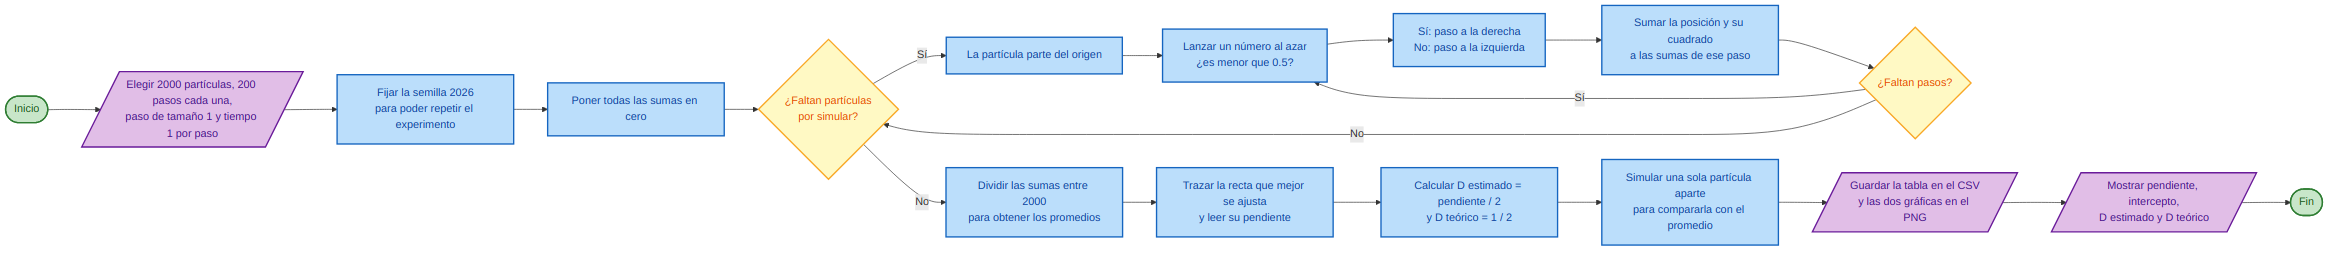

In [ ]:
#DIAGRAMA DE FLUJO C
from IPython.display import Image
Image(filename="/content/parteC_diagrama.png")


[OK] Datos exportados exitosamente a 'caminata_difusion.csv'


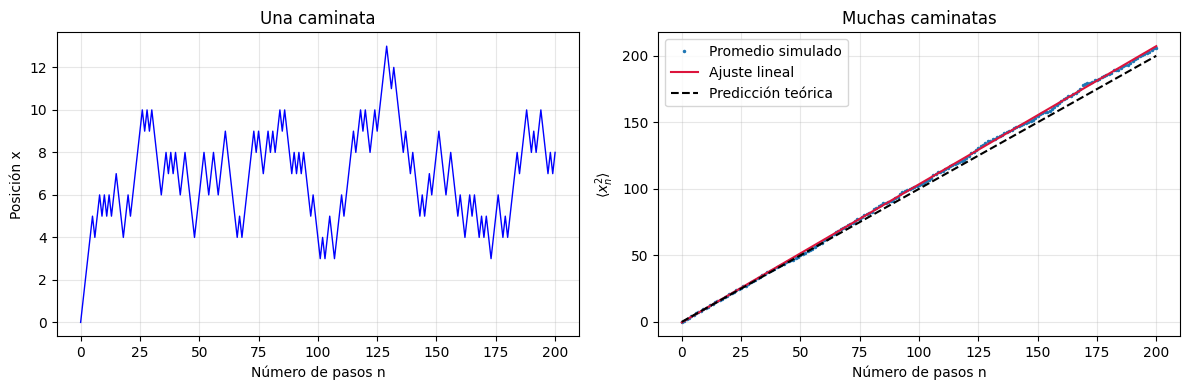

[OK] Figura guardada exitosamente como 'caminata_difusion.png'
Pendiente=1.03839; intercepto=-0.40870
D estimado=0.51919; D teórico=0.50000 (longitud²/tiempo)


In [28]:
import matplotlib.pyplot as plt

# --- Parámetros del experimento ---
K, N = 2000, 200                                                     # caminantes y pasos por caminante
a, delta_t = 1.0, 1.0                                                # longitud de paso e intervalo de tiempo
semilla = 2026                                                       # semilla del resultado entregado

# --- Simulación y ajuste lineal de <x_n^2> frente a n ---
media_x, media_x2 = simular_caminatas(K, N, a, semilla)
pasos = list(range(N + 1))
pendiente, intercepto = ajuste_lineal(pasos, media_x2)

# --- Coeficiente de difusión: estimado (del ajuste) y teórico ---
D_estimado = pendiente/ (2.0*delta_t)                                # pendiente / (2*delta_t)
D_teorico = (a**2)/ (2*delta_t)                                      # a*a / (2*delta_t)
ajuste = [pendiente*n + intercepto for n in pasos]                   # recta ajustada, para graficar

# --- Una trayectoria individual, para comparar con el promedio ---
# La semilla distinta permite mostrar una trayectoria reproducible e independiente.
trayectoria = caminar(N, a, random.Random(2027))

# --- Guardar los resultados en un archivo CSV ---
with open("caminata_difusion.csv", "w", encoding="utf-8") as archivo:
    archivo.write("n,media_x,media_x2,ajuste\n")
    for n in pasos:
        archivo.write(f"{n},{media_x[n]},{media_x2[n]},{ajuste[n]}\n")

#imprimir un mensaje que recuerde que los datos fueron exportados a csv
print("\n[OK] Datos exportados exitosamente a 'caminata_difusion.csv'")

# --- Figura: trayectoria individual (izquierda) y promedios (derecha) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(pasos, trayectoria, color="blue" if "blue" in locals() else "blue", linewidth=1)
ax1.set(xlabel="Número de pasos n", ylabel="Posición x", title="Una caminata")
ax2.plot(pasos, media_x2, ".", markersize=3, label="Promedio simulado")
ax2.plot(pasos, ajuste, color="crimson", label="Ajuste lineal")
ax2.plot(pasos, [n*a*a for n in pasos], "--", color="black", label="Predicción teórica")
ax2.set(xlabel="Número de pasos n", ylabel=r"$\langle x_n^2\rangle$", title="Muchas caminatas")
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.savefig("caminata_difusion.png", dpi=180, bbox_inches="tight")
plt.show()

#imprimir un mensaje que recuerde que la figura fue exportada en png
print("[OK] Figura guardada exitosamente como 'caminata_difusion.png'")


# --- Resumen numérico ---
print(f"Pendiente={pendiente:.5f}; intercepto={intercepto:.5f}")
print(f"D estimado={D_estimado:.5f}; D teórico={D_teorico:.5f} (longitud²/tiempo)")

### Exploración requerida

Repita la simulación con, por ejemplo, $K=100$ y $K=2000$, conservando $N$, $a$, $\Delta t$ y la semilla. Calcule el coeficiente de difusión $D$ en cada caso. Explique por qué la cercanía a $D_{\rm teórico}$ **no tiene que mejorar de manera monótona** en solo dos ejecuciones, aunque la precisión típica sí mejora al promediar más caminatas. Si cambia la semilla, documente el cambio.

**Extensión opcional (Computational Physics, Giordano, ejercicio 7.3):** modifique las probabilidades de derecha e izquierda. Compare $\langle x_n^2\rangle$ con $\operatorname{Var}(x_n)=\langle x_n^2\rangle-\langle x_n\rangle^2$. Discuta cuál separa la dispersión de la deriva promedio. No use $m/(2\Delta t)$ de $\langle x^2\rangle$ como coeficiente de difusión en presencia de deriva.

In [7]:
#repetimos la simulación, para ello definimos parametros que se conservan y los que cambian por aparte

#parametros comunes
N, a, delta_t = 200, 1.0, 1.0
semilla=2026
pasos= list(range(N+1))
D_teorico= (a**2) / (2.0*delta_t)

#SIMULACION CON K=100
K_100 = 100
_, x2_100 = simular_caminatas(K_100, N, a, semilla)
m_100, _ = ajuste_lineal(pasos, x2_100)
D_100 = m_100 / (2.0*delta_t)

#SIMULACION CON K=2000
K_2000 = 2000
_,x2_2000 = simular_caminatas(K_2000, N, a, semilla)
m_2000, _ = ajuste_lineal(pasos, x2_2000)
D_2000 = m_2000 / (2.0*delta_t)

print(f"D teorico: {D_teorico:.4f}")
print(f"D con K=100: {D_100:.4f}")
print(f"D con K=2000: {D_2000:.4f}")

D teorico: 0.5000
D con K=100: 0.6676
D con K=2000: 0.5192


La cercania de D_teorico no tiene que mejorar siempre que dos ejecuciones, porque el metodo de Monte Carlo depende completamente del azar. Con solo 100 caminantes, una ejecucion puede tener una cierta "suerte de probabildiad", y por ende, producir un valor muy cercano al valor teorico, aunque la muestra sea pequeña relativamente.

Al aumentar K de 100 a 2000, disminuye la incertidumbre tipica y el resultado suele ser mas preciso. Sin embargo, esto no significa que cada ejecucion de 2000 caminantes tenga que ser estrictamente mas cercana que cualquier ejecucion de 100,  ya que una muestra pequeña puede acertar por casualidad. El azar influye bastante.

## **Parte D — Efecto de un mal generador sobre el coeficiente de difusión**

En las diapositivas se mostró que el generador congruencial $(a,c,M,r_1)=(57,1,256,10)$ produce pares consecutivos alineados en una rejilla. Ahora se medirá el efecto de ese defecto sobre **un resultado físico**: el coeficiente de difusión $D$.

La clase `GeneradorLCG` de la celda siguiente ya está completa. Tiene un método `random()` que devuelve $r_i/M$, igual que `random.Random`; por eso puede entregarse directamente a `simular_caminatas` mediante el argumento `generador`. Ejecútela sin modificarla.

### Actividades

1. Ejecute la simulación con $K=2000$, $N=200$, $a=1$, $\Delta t=1$ usando tres generadores: `random.Random(2026)`, el LCG deficiente `GeneradorLCG(57, 1, 256, 10)` y el LCG de parámetros de `drand48`, `GeneradorLCG(0x5DEECE66D, 11, 2**48, 10)`.
2. Ajuste una recta a $\langle x_n^2\rangle$ en cada caso con `ajuste_lineal` y calcule el coeficiente de difusión $D$. Guarde los resultados en `D_lcg_malo` y `D_drand48`.
3. Represente $\langle x_n^2\rangle$ frente a $n$ para los tres generadores en una misma figura.
4. Guarde en `trayectoria_lcg_larga` **una sola** caminata de 1024 pasos con el LCG deficiente e imprima la posición en $n = 0, 256, 512, 768, 1024$. Explique el resultado usando el período del generador.
5. Responda: ¿qué coeficiente de difusión habría reportado un investigador que usara este generador sin probarlo? ¿Por qué las pruebas de media y de pares consecutivos del Ejercicio 1 son necesarias antes de simular?


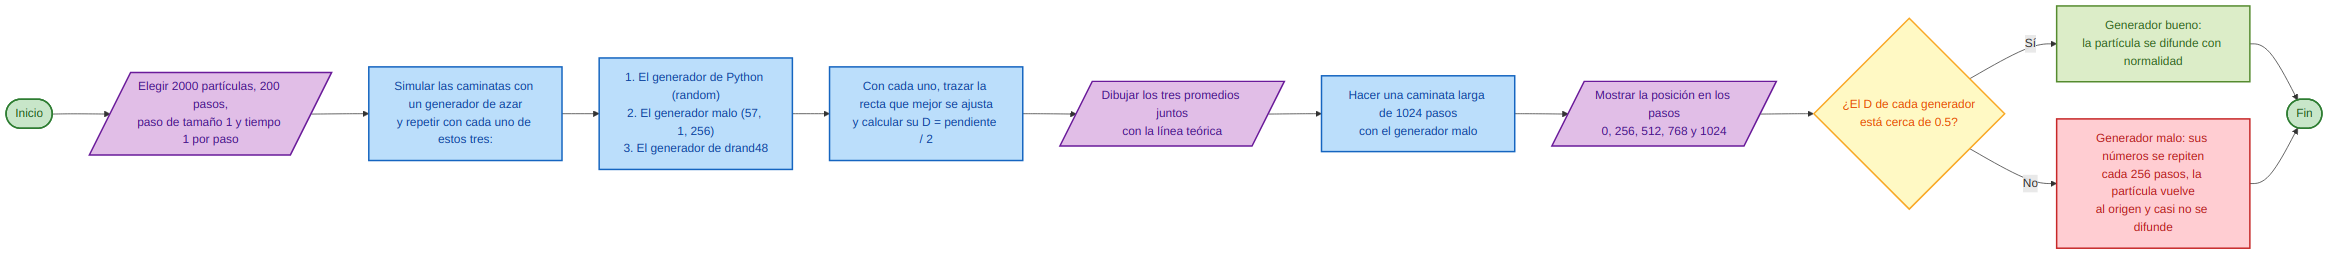

In [ ]:
#DIAGRAMA DE FLUJO D
from IPython.display import Image
Image(filename="/content/parteD_diagrama.png")

In [8]:
class GeneradorLCG:
    """Generador lineal congruente r_{i+1} = (a r_i + c) mod M.

    El método random() devuelve r/M en [0, 1), con la misma interfaz que
    random.Random, de modo que puede reemplazarlo en simular_caminatas.
    """

    # --- Constructor: guarda los parámetros y el estado inicial (la semilla) ---
    def __init__(self, a, c, M, semilla):
        self.a, self.c, self.M = a, c, M
        self.r = semilla % M          # el estado siempre está en 0, ..., M-1

    # --- Un número nuevo: actualiza el estado y lo escala a [0, 1) ---
    def random(self):
        self.r = (self.a*self.r + self.c) % self.M   # recurrencia congruencial
        return self.r / self.M                       # división real


# --- Comprobación con la secuencia de las diapositivas (a=4, c=1, M=9, r1=3) ---
demo = GeneradorLCG(4, 1, 9, 3)
print([round(demo.random()*9) for _ in range(9)])  # debe dar 4, 8, 6, 7, 2, 0, 1, 5, 3


[4, 8, 6, 7, 2, 0, 1, 5, 3]


D con random.Random : 0.5192
D con LCG deficiente: 0.0862
D con LCG drand48   : 0.4855   (teórico 0.5)


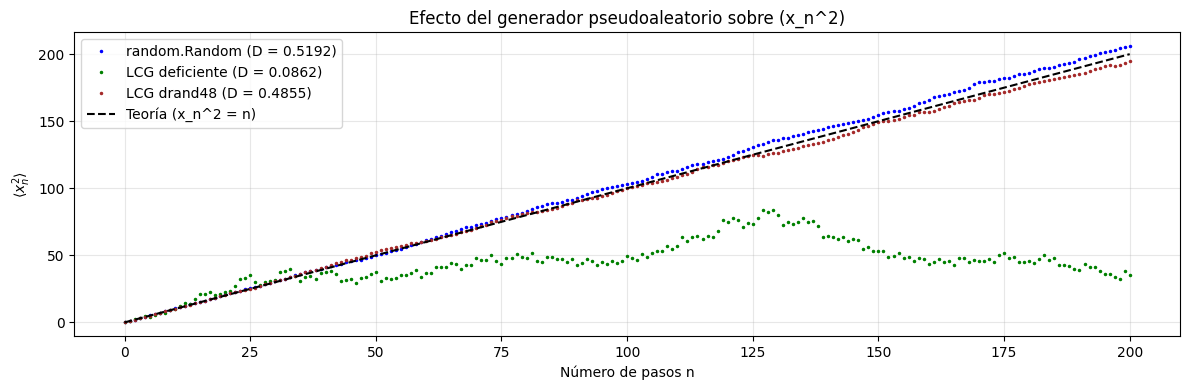

Posición en los pasos:    [0.0, 0.0, 0.0, 0.0, 0.0]


In [9]:
## ACTIVIDAD 1 ##
# --- Parámetros comunes a los tres experimentos ---
K_gen, N_gen = 2000, 200
pasos_gen = list(range(N_gen + 1))

# --- Misma simulación con tres generadores distintos ---
_, x2_bueno = simular_caminatas(K_gen, N_gen, 1.0, 2026)                                                       # random.Random
_, x2_malo = simular_caminatas(K_gen, N_gen, 1.0, None, generador=GeneradorLCG(57,1,256,10))                   # LCG (57, 1, 256, 10)
_, x2_drand48 = simular_caminatas(K_gen, N_gen, 1.0, None, generador=GeneradorLCG(0x5DEECE66D, 11, 2**48, 10))  # LCG de drand48, semilla 10

## ACTIVIDAD 2 ##
# --- Pendiente de <x_n^2> para cada generador ---
m_bueno, _ = ajuste_lineal(pasos_gen, x2_bueno)
m_malo, _ = ajuste_lineal(pasos_gen, x2_malo)
m_drand48, _ = ajuste_lineal(pasos_gen, x2_drand48)

# --- Coeficiente de difusión D = pendiente / (2 dt), con dt = 1 ---
D_bueno = m_bueno/2
D_lcg_malo = m_malo/2
D_drand48 = m_drand48/2
print(f"D con random.Random : {D_bueno:.4f}")
print(f"D con LCG deficiente: {D_lcg_malo:.4f}")
print(f"D con LCG drand48   : {D_drand48:.4f}   (teórico 0.5)")

## ACTIVIDAD 3 ##
# --- Gráfica comparativa ---
plt.figure(figsize=(12, 4))
plt.plot(pasos_gen, x2_bueno, ".", markersize=3, label=f"random.Random (D = {D_bueno:.4f})", color="Blue")
plt.plot(pasos_gen, x2_malo, ".", markersize=3, label=f"LCG deficiente (D = {D_lcg_malo:.4f})", color="Green")
plt.plot(pasos_gen, x2_drand48, ".", markersize=3, label=f"LCG drand48 (D = {D_drand48:.4f})", color="Brown")
plt.plot(pasos_gen, pasos_gen, "--", color="Black", label="Teoría (x_n^2 = n)")  #el teorico por asi decirlo
plt.title("Efecto del generador pseudoaleatorio sobre (x_n^2)")
plt.xlabel("Número de pasos n")
plt.ylabel(r"$\langle x_n^2\rangle$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparacion_generadores.png", dpi=180)
plt.show()

## ACTIVIDAD 4 ##
# --- Una caminata larga con el LCG deficiente ---
# Guarde la caminata completa para que PASS/FAIL pueda revisarla.
trayectoria_lcg_larga = caminar(1024, 1.0, GeneradorLCG(57, 1, 256, 10))
print("Posición en los pasos:   ", [trayectoria_lcg_larga[n] for n in (0, 256, 512, 768, 1024)])

El generador LCG tiene un ciclo de 256 numeros, y en cada ciclo genera exactamente 128 pasos positivos y 128 negativos (se dividen uniformemente). Es por ello que, cada 256 pasos los movimientos se compensan y la particula vuelve a su posicion original (x=0). Como 1024 pasos son 4 ciclos completos, en los pasos que nos piden (0, 256, 512, 768,1024) la posicion termina siendo siempre cero, ya que son multiplos de 256 (un ciclo).

Ademas, la caminata deja de comportarse como una caminata aleatoria, y empieza a repetir el mismo patron de forma reiterada, por lo cual, la particula no se aleja normalmente del origen y genera que en (x_n^2) no crezca como deberia. Por ende, la difusion se da D=0.0862, un valor bastante bajo del valor teorico D=0.5

**ACTIVIDAD 5**


*¿Qué coeficiente de difusión habría reportado un investigador desprevenido?:*

Lo mas probable es que hubiese reportado un valor de D=0.0862, teniendo un mayor E.R.P comparado a las otras medidas, ya que posee una diferencia mucho mas grande al valor teorico que las otras.


##
*¿Por qué las pruebas de media y de pares consecutivos del Ejercicio 1 son necesarias antes de simular?:*

El LCG deficiente pasa la prueba de valor promedio (x=0.4981 = 0.5 redondeado segun la teoria), haciendo parecer de forma erronea que el generador distribuye bien los numeros. Sin embargo, al graficar los pares consecutivos, el LCG deficiente refleja tener unas "lineas" paralelas de forma consecutiva que forman patrones en escala, lo cual puede entenderse a que estos numeros estan relacionados.

## **Parte E — Difusión en unidades reales**

Hasta ahora $a=1$ y $\Delta t=1$ en unidades arbitrarias. Para dar sentido físico al resultado, considere una molécula de oxígeno disuelta en agua a temperatura ambiente, cuyo coeficiente de difusión $D$ es aproximadamente

$$D_{\rm O_2}\approx 2\times10^{-9}\ \text{m}^2/\text{s}.$$

El modelo de caminata reproduce ese valor si la longitud del paso y el intervalo cumplen $D=a^2/(2\Delta t)$. El tiempo característico para que el desplazamiento cuadrático medio alcance $L^2$ es, en una dimensión,

$$t(L)\approx\frac{L^2}{2D}.$$

### Actividades

1. Con $\Delta t = 1\ \mu\text{s}$, calcule la longitud de paso `a_fisico` (en metros) que reproduce $D_{\rm O_2}$.
2. Convierta la pendiente `pendiente` obtenida en la Parte C (en unidades de $a^2$ por paso) a un coeficiente de difusión en m²/s: $D_{\rm sim} = m\,a_{\rm fisico}^2/(2\Delta t)$. Compárelo con $D_{\rm O_2}$.
3. Calcule `t_celula`, `t_mm` y `t_cm`: el tiempo para difundir $L = 10\ \mu\text{m}$ (el tamaño de una célula), $1$ mm y $1$ cm. Exprese cada uno en la unidad más legible (s, min, h).
4. Calcule también el tiempo para $L = 1$ m en agua quieta y expréselo en años.
5. ¿Cuántos pasos $N$ necesitaría la simulación para representar la difusión a lo largo de 1 cm con el paso `a_fisico`? Comente por qué, a escalas grandes, se usa la ecuación de difusión en lugar de simular cada paso.
6. Discuta brevemente: la difusión basta para transportar oxígeno dentro de una célula, pero ¿basta para mezclar un contaminante en un lago? ¿Qué otro mecanismo de transporte domina a escalas grandes?


**Interpretación:** este tiempo corresponde a una distancia raíz cuadrática media $x_{\mathrm{rms}}=L$. No es el tiempo en que todas las partículas alcanzan $L$, ni garantiza mezcla completa. El paso `a_fisico` es una longitud efectiva de este modelo: no se identifica necesariamente con la distancia entre colisiones moleculares. El valor de $D_{\rm O_2}$ se usa como dato aproximado del ejercicio; depende de las condiciones del medio.


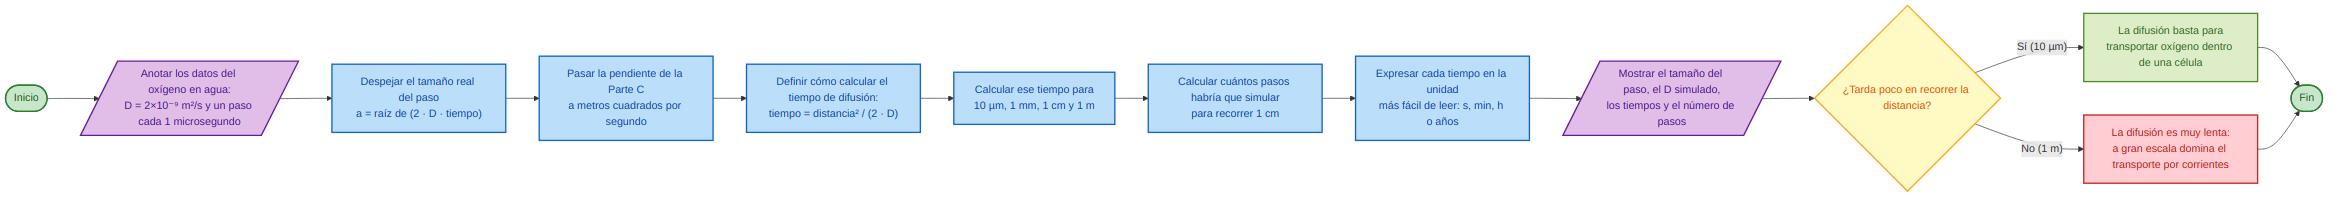

In [ ]:
#DIAGRAMA DE FLUJO E
from IPython.display import Image
Image(filename="/content/parteE_diagrama.png")

In [22]:
import math

# --- Datos físicos ---
D_O2 = 2e-9                                                                     # m^2/s, coeficiente de difusión del oxígeno en agua (aprox.)
dt_fisico = 1e-6                                                                # s, intervalo de tiempo entre pasos


# --- Longitud de paso y coeficiente de difusión simulado ---

## ACTIVIDAD 1 ##
a_fisico = math.sqrt(2.0*D_O2*dt_fisico)                                        # m, despejado de D = a^2/(2 dt)
## ACTIVIDAD 2 ##
D_sim = (pendiente*(a_fisico**2)/(2.0*dt_fisico))                               # m^2/s, a partir de la pendiente de la Parte C

## ACTIVIDAD 3 Y ACTIVIDAD 4 ##
# --- Tiempo característico de difusión ---
def tiempo_difusion(L, D):
    return (L**2)/(2.0*D)                                                       #Tiempo t = L^2/(2D) para alcanzar una distancia RMS L en una dimensión

# --- Tiempos para distintas escalas de longitud ---
t_celula = tiempo_difusion(10e-6, D_O2)                                         # L, una célula (10 µm)
t_mm = tiempo_difusion(1e-3, D_O2)                                              # L, 1 mm
t_cm = tiempo_difusion(1e-2, D_O2)                                              # L, 1 cm
t_m = tiempo_difusion(1.0, D_O2)                                                # L, 1 m

## ACTIVIDAD 5 ##
# --- Número de pasos que exigiría simular 1 cm con el paso a_fisico ---
N_cm = (1e-2 / a_fisico)**2                                                     #N_cm = (L /a_fisico)^2


# --- Resultados en unidades legibles ---
print(f"a = {a_fisico*1e9:.1f} nm;  D_sim = {D_sim:.3e} m^2/s  (referencia {D_O2:.1e})")
print(f"10 µm: {t_celula:.3g} s")
print(f"1 mm : {t_mm:.3g} s = {t_mm/60:.3g} min")
print(f"1 cm : {t_cm:.3g} s = {t_cm/3600:.3g} h")
print(f"1 m  : {t_m/(3600*24*365.25):.3g} años")
print(f"Pasos para 1 cm: {N_cm:.2e}")


a = 63.2 nm;  D_sim = 2.077e-09 m^2/s  (referencia 2.0e-09)
10 µm: 0.025 s
1 mm : 250 s = 4.17 min
1 cm : 2.5e+04 s = 6.94 h
1 m  : 7.92 años
Pasos para 1 cm: 2.50e+10


**ACTIVIDAD 5**

El simular 2.5 x $10^{10}$ pasos por cada particula, se necesitarian muchas iteracciones y memoria. En una observación a grande escala, las fluctuaciones individuales de las particulas se promedian, por lo que resulta mucho mas eficiente resolver numericamente la ecuacion diferencial parcial de difusion continua.

**ACTIVIDAD 6**

En el interior de la celula la distancia usual es de $10 \mu\text{m}$, mientras que el tiempo de difusion es de 0.025s. Por ende, la difusion molecular pura es un mecanismo muy eficiente para trasportar oxigeno y nutrientes.
##
Por otro lado, la difusion molecular en agua quieta necesita 7.92 años para recorrer 1m, y al tener una difusion molecular pura muy baja, hace que sea ineficiente para contaminar a una gran escala.
##
Ademas, a una escala grande, el proceso que domina la mezcla es el transporte por adveccion y conveccion impulsado por flujos inestables, como lo son el viento o variaciones de la densidad del agua.

# **PARTE F:**
Calcule el error relativo porcentual mediante


$$\text{diferencia porcentual}=100\,\frac{|D_{\rm estimado}-D_{\rm teórico}|}{D_{\rm teórico}}.$$

Con el fin de incluirlo en el reporte y realizar conclusiones.

In [26]:
D_estimada = D_2000
D_teorica = 0.50000
Erelav = abs((D_estimada - D_teorica)/D_teorica) * 100        #realizamos la formula

print(f"El error relativo porcentual (Dk2000) es: {Erelav:.2f}%")      #imprimimos con 2 decimales

#definimos el valor teorico para la D_sin

D_teorico_SI = 2e-9

#calculamos ERP de las demas medidas
erp_k100 = abs((D_k100 - D_teorica)/D_teorica) * 100
erp_LCG = abs((D_LCG - D_teorica)/D_teorica) * 100
erp_sim = abs((D_sim - D_teorico_SI)/D_teorico_SI) * 100

#imprimimos

print(f"El error relativo porcentual (Dk100) es: {erp_k100:.2f}%")
print(f"El error relativo porcentual (D LCG) es: {erp_LCG:.2f}%")
print(f"El error relativo porcentual (D_sim) es: {erp_sim:.2f}%")

El error relativo porcentual (Dk2000) es: 3.84%
El error relativo porcentual (Dk100) es: 33.52%
El error relativo porcentual (D LCG) es: 82.76%
El error relativo porcentual (D_sim) es: 3.84%


## **Verificación final PASS/FAIL**

Ejecute esta celda después de completar el taller. Las pruebas usan entradas controladas para verificar las funciones y revisan los archivos generados. La comparación estadística del valor de $D$ permite fluctuaciones razonables; no exige igualdad exacta. **Un PASS no reemplaza la revisión del código, las unidades, la figura y la interpretación física.**

In [27]:
# --- Bibliotecas para leer el CSV y comparar números reales ---
import csv
import math
from pathlib import Path

# --- Registro de resultados: imprime PASS/FAIL y guarda cada veredicto ---
veredictos = []
def informar(nombre, condicion, detalle=""):
    estado = "PASS" if condicion else "FAIL"
    veredictos.append(condicion)
    print(f"{estado} | {nombre}" + (f" — {detalle}" if detalle else ""))

# --- Generador de prueba: devuelve valores fijados de antemano ---
class RngControlado:
    def __init__(self, valores):
        self.valores = iter(valores)
    def random(self):
        return next(self.valores)

# --- Prueba 1: regla del paso (umbral en 0.5) ---
try:
    pasos_prueba = [generar_paso(RngControlado([u]), 2.0) for u in (0.0, 0.49, 0.5, 0.99)]
    informar("Regla del paso y umbral 0.5", pasos_prueba == [2.0, 2.0, -2.0, -2.0])
except Exception as exc:
    informar("Regla del paso y umbral 0.5", False, str(exc))

# --- Prueba 2: trayectoria con números controlados ---
try:
    posiciones_prueba = list(caminar(4, 2.0, RngControlado([0.1, 0.7, 0.2, 0.8])))
    informar("Trayectoria y posición inicial", posiciones_prueba == [0.0, 2.0, 0.0, 2.0, 0.0])
except Exception as exc:
    informar("Trayectoria y posición inicial", False, str(exc))

# --- Prueba 3: ajuste lineal con datos exactos ---
try:
    m_prueba, b_prueba = ajuste_lineal([0, 1, 2, 3], [2, 5, 8, 11])
    informar("Ajuste lineal con datos conocidos", math.isclose(m_prueba, 3.0, abs_tol=1e-10) and math.isclose(b_prueba, 2.0, abs_tol=1e-10))
except Exception as exc:
    informar("Ajuste lineal con datos conocidos", False, str(exc))

# --- Pruebas 4-7: estructura, reproducibilidad, simetría y crecimiento difusivo ---
try:
    mx1, mx21 = simular_caminatas(2000, 100, 1.0, 12345)
    mx2, mx22 = simular_caminatas(2000, 100, 1.0, 12345)
    estructura = (len(mx1) == len(mx21) == 101 and
                  math.isclose(mx1[0], 0.0) and math.isclose(mx21[0], 0.0) and
                  all(math.isfinite(float(v)) for v in list(mx1) + list(mx21)))
    informar("Longitud, origen y valores finitos", estructura)
    informar("Reproducibilidad con la misma semilla", list(mx1) == list(mx2) and list(mx21) == list(mx22))
    if estructura:
        exactitud_media = all(abs(mx1[n]) <= 0.20*math.sqrt(n) + 0.1 for n in (25, 50, 100))
        informar("Media de posición compatible con simetría", exactitud_media)
        m_test, _ = ajuste_lineal(list(range(101)), mx21)
        informar("Crecimiento difusivo promedio", math.isfinite(m_test) and abs(m_test - 1.0) < 0.15, f"pendiente={m_test:.4f}")
    else:
        informar("Media de posición compatible con simetría", False)
        informar("Crecimiento difusivo promedio", False)
except Exception as exc:
    for nombre in ("Longitud, origen y valores finitos", "Reproducibilidad con la misma semilla", "Media de posición compatible con simetría", "Crecimiento difusivo promedio"):
        informar(nombre, False, str(exc))

# --- Prueba 8: parámetros inválidos deben producir ValueError ---
try:
    rechazos = []
    for llamada in (lambda: caminar(-1, 1.0, random.Random(1)),
                    lambda: simular_caminatas(0, 10, 1.0, 1),
                    lambda: ajuste_lineal([1, 1], [2, 3])):
        try:
            llamada()
            rechazos.append(False)
        except ValueError:
            rechazos.append(True)
    informar("Parámetros y ajuste degenerado rechazados", all(rechazos))
except Exception as exc:
    informar("Parámetros y ajuste degenerado rechazados", False, str(exc))

# --- Prueba 9: archivo CSV completo y consistente ---
try:
    datos = list(csv.DictReader(open("caminata_difusion.csv", encoding="utf-8")))
    columnas = set(datos[0]) if datos else set()
    valido = (len(datos) == N + 1 and columnas == {"n", "media_x", "media_x2", "ajuste"}
              and [int(fila["n"]) for fila in datos] == list(range(N+1)))
    if valido:
        valido = all(math.isclose(float(fila["media_x2"]), float(media_x2[i]), abs_tol=1e-10)
                     and math.isclose(float(fila["ajuste"]), pendiente*i + intercepto, abs_tol=1e-9)
                     for i, fila in enumerate(datos))
    informar("CSV completo y consistente con el ajuste", valido)
except Exception as exc:
    informar("CSV completo y consistente con el ajuste", False, str(exc))

# --- Prueba 10: conversión de la pendiente al coeficiente de difusión ---
try:
    correcto_D = (math.isclose(D_estimado, pendiente/(2*delta_t), rel_tol=1e-10, abs_tol=1e-10)
                   and math.isclose(D_teorico, a*a/(2*delta_t), rel_tol=1e-10, abs_tol=1e-10))
    informar("Conversión de la pendiente al coeficiente de difusión", correcto_D)
except Exception as exc:
    informar("Conversión de la pendiente al coeficiente de difusión", False, str(exc))

# --- Prueba 11: simular_caminatas acepta un generador externo (Parte D) ---
try:
    _, x2_ctrl = simular_caminatas(1, 2, 1.0, None, generador=RngControlado([0.1, 0.7]))
    informar("simular_caminatas acepta un generador externo", [float(t) for t in x2_ctrl] == [0.0, 1.0, 0.0])
except Exception as exc:
    informar("simular_caminatas acepta un generador externo", False, str(exc))

# --- Pruebas 12-13: coeficiente de difusión con el LCG deficiente y con drand48 ---
try:
    informar("LCG deficiente: resultado del experimento especificado", math.isfinite(D_lcg_malo) and math.isclose(D_lcg_malo, 0.08623725432244717, rel_tol=1e-6, abs_tol=1e-8), f"D_lcg_malo={D_lcg_malo:.4f}")
    informar("LCG drand48: coeficiente de difusión compatible con 0.5", abs(D_drand48 - 0.5) < 0.075, f"D_drand48={D_drand48:.4f}")
except Exception as exc:
    informar("LCG deficiente: resultado del experimento especificado", False, str(exc))
    informar("LCG drand48: coeficiente de difusión compatible con 0.5", False, str(exc))

# --- Pruebas 14-15: unidades reales (Parte E) ---
try:
    ok_a = math.isclose(a_fisico, math.sqrt(2*D_O2*dt_fisico), rel_tol=1e-9)
    ok_Dsim = math.isclose(D_sim, pendiente*a_fisico**2/(2*dt_fisico), rel_tol=1e-9)
    informar("Paso físico y coeficiente de difusión en m²/s", ok_a and ok_Dsim, f"a={a_fisico*1e9:.1f} nm, D_sim={D_sim:.2e} m²/s")
    ok_t = (math.isclose(t_celula, 0.025, rel_tol=1e-9) and math.isclose(t_cm, 2.5e4, rel_tol=1e-9)
            and math.isclose(t_mm, 250.0, rel_tol=1e-9) and math.isclose(t_m, 2.5e8, rel_tol=1e-9)
            and math.isclose(N_cm, (1e-2/a_fisico)**2, rel_tol=1e-6))
    informar("Tiempos de difusión y número de pasos", ok_t, f"t(10 µm)={t_celula:.3g} s, t(1 cm)={t_cm/3600:.2f} h")
except Exception as exc:
    informar("Paso físico y coeficiente de difusión en m²/s", False, str(exc))
    informar("Tiempos de difusión y número de pasos", False, str(exc))

# Prueba determinista de la caminata larga: no llama a las funciones del estudiante.
try:
    estado_ref = 10
    x_ref = 0.0
    recorrido_ref = [x_ref]
    for _ in range(1024):
        estado_ref = (57*estado_ref + 1) % 256
        x_ref += 1.0 if estado_ref/256 < 0.5 else -1.0
        recorrido_ref.append(x_ref)
    informar("Caminata larga con LCG: trayectoria y retornos periódicos",
             list(trayectoria_lcg_larga) == recorrido_ref)
except Exception as exc:
    informar("Caminata larga con LCG: trayectoria y retornos periódicos", False, str(exc))

# --- Prueba 16: la figura fue guardada ---
figura = Path("caminata_difusion.png")
informar("Figura generada", figura.is_file() and figura.stat().st_size > 1000)
# --- Resumen final ---
print(f"Resumen: {sum(veredictos)}/{len(veredictos)} PASS")

PASS | Regla del paso y umbral 0.5
PASS | Trayectoria y posición inicial
PASS | Ajuste lineal con datos conocidos
PASS | Longitud, origen y valores finitos
PASS | Reproducibilidad con la misma semilla
PASS | Media de posición compatible con simetría
PASS | Crecimiento difusivo promedio — pendiente=1.0147
PASS | Parámetros y ajuste degenerado rechazados
PASS | CSV completo y consistente con el ajuste
PASS | Conversión de la pendiente al coeficiente de difusión
PASS | simular_caminatas acepta un generador externo
PASS | LCG deficiente: resultado del experimento especificado — D_lcg_malo=0.0862
PASS | LCG drand48: coeficiente de difusión compatible con 0.5 — D_drand48=0.4855
PASS | Paso físico y coeficiente de difusión en m²/s — a=63.2 nm, D_sim=2.08e-09 m²/s
PASS | Tiempos de difusión y número de pasos — t(10 µm)=0.025 s, t(1 cm)=6.94 h
PASS | Caminata larga con LCG: trayectoria y retornos periódicos
PASS | Figura generada
Resumen: 17/17 PASS
